In [52]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
X,y = make_classification(n_samples = 500,n_features = 2,n_redundant=0,n_informative=2, n_clusters_per_class=1,n_classes=2)
arr = np.hstack((X, (y.reshape(-1,1))))
df = pd.DataFrame(arr,columns = ['x1','x2','y'])
df

,x1,x2,y
0,-1.512580,0.064045,0.0
1,-1.632590,-0.880540,0.0
2,0.548525,0.222466,1.0
3,-3.935765,1.534604,0.0
4,-0.974342,-1.875441,0.0
...,...,...,...
495,-2.216342,-0.058331,0.0
496,1.948009,-0.553501,1.0
497,-1.238520,-0.701492,0.0
498,-1.182725,-0.943506,0.0


<Axes: xlabel='x1', ylabel='x2'>

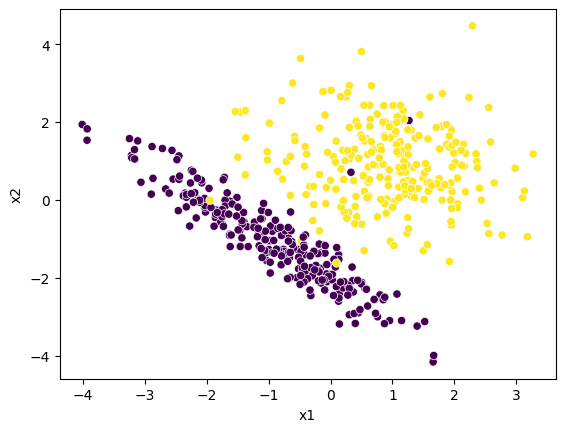

In [53]:
import seaborn as sns
sns.scatterplot(data = df, x = df['x1'], y = df['x2'], c = df['y'])

In [54]:
def step_fun(num):
  if num >= 0 :
    return 1
  else :
    return 0
def perceptron_UKD(epochs = 100, l_rate = 0.01, df:pd.DataFrame = df):
  X = df.drop(columns = ['y'])
  y = df['y']
  X_mat = np.insert(X,0,1,axis = 1)
  W = np.ones(shape = (1,X_mat.shape[1]))
  W[:,0] = 0
  for i in range(epochs):
    idx = np.random.randint(0,X_mat.shape[0])
    X_random_point = X_mat[idx,:]
    y_random_point = y[idx]
    y_pred = step_fun(np.dot(W,X_random_point))
    W = W + l_rate*(y_random_point - y_pred)*X_random_point
  return W

In [55]:
W_arr = perceptron_UKD(3000,0.1,df)

In [56]:
W_arr

array([[0.3       , 0.35141695, 0.31025183]])

In [57]:
import matplotlib.pyplot as plt
x_point = np.linspace(-3,3)
x_point


array([-3.        , -2.87755102, -2.75510204, -2.63265306, -2.51020408,
       -2.3877551 , -2.26530612, -2.14285714, -2.02040816, -1.89795918,
       -1.7755102 , -1.65306122, -1.53061224, -1.40816327, -1.28571429,
       -1.16326531, -1.04081633, -0.91836735, -0.79591837, -0.67346939,
       -0.55102041, -0.42857143, -0.30612245, -0.18367347, -0.06122449,
        0.06122449,  0.18367347,  0.30612245,  0.42857143,  0.55102041,
        0.67346939,  0.79591837,  0.91836735,  1.04081633,  1.16326531,
        1.28571429,  1.40816327,  1.53061224,  1.65306122,  1.7755102 ,
        1.89795918,  2.02040816,  2.14285714,  2.26530612,  2.3877551 ,
        2.51020408,  2.63265306,  2.75510204,  2.87755102,  3.        ])

In [58]:
W_arr = W_arr.reshape(-1)
w0 = W_arr[0]
w1 = W_arr[1]
w2 = W_arr[2]

In [59]:
y_point = (-w0/w2) - (w1/w2)*x_point

In [60]:
y_point

array([ 2.43109232,  2.29239646,  2.15370059,  2.01500472,  1.87630886,
        1.73761299,  1.59891712,  1.46022125,  1.32152539,  1.18282952,
        1.04413365,  0.90543779,  0.76674192,  0.62804605,  0.48935018,
        0.35065432,  0.21195845,  0.07326258, -0.06543328, -0.20412915,
       -0.34282502, -0.48152089, -0.62021675, -0.75891262, -0.89760849,
       -1.03630435, -1.17500022, -1.31369609, -1.45239196, -1.59108782,
       -1.72978369, -1.86847956, -2.00717542, -2.14587129, -2.28456716,
       -2.42326303, -2.56195889, -2.70065476, -2.83935063, -2.97804649,
       -3.11674236, -3.25543823, -3.39413409, -3.53282996, -3.67152583,
       -3.8102217 , -3.94891756, -4.08761343, -4.2263093 , -4.36500516])

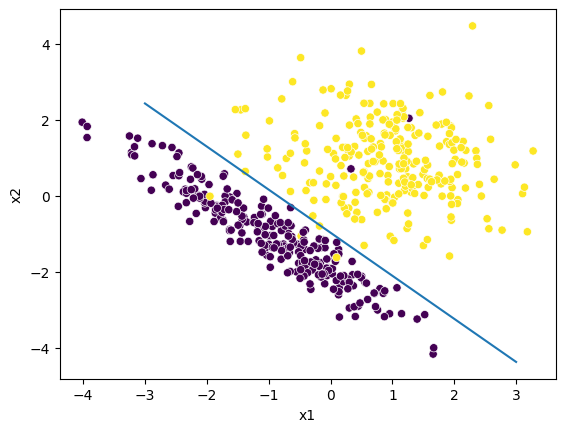

In [61]:
import seaborn as sns
sns.scatterplot(data = df, x = df['x1'], y = df['x2'], c = df['y'])
plt.plot(x_point,y_point)